# 01. EDA — разведочный анализ данных
Telco Customer Churn


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


## 1. Загрузка данных


In [2]:
import pandas as pd
from src.data_loader import ensure_raw_data

raw_path = ensure_raw_data()
df = pd.read_csv(raw_path)
df.head()


[data_loader] Found existing E:\.PetProjects\Churn Predictions\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv, skipping download.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
from ydata_profiling import ProfileReport

C:\Users\Timur\AppData\Local\Temp\ipykernel_21084\44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [5]:
ydata_report = ProfileReport(df, title="Report for Telco-Customer-Churn")

In [7]:
ydata_report.to_file(PROJECT_ROOT / "data" / "raw" / "ydata_profiling_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 2. Размер, типы, пропуски


In [4]:
df.info()
df.isna().sum()
(df['TotalCharges'].str.strip() == '').sum()
# TODO: df.isna().sum(), df['TotalCharges'] blank-string check


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(11)

## 3. Распределение таргета (Churn)
Проверяем дисбаланс классов.


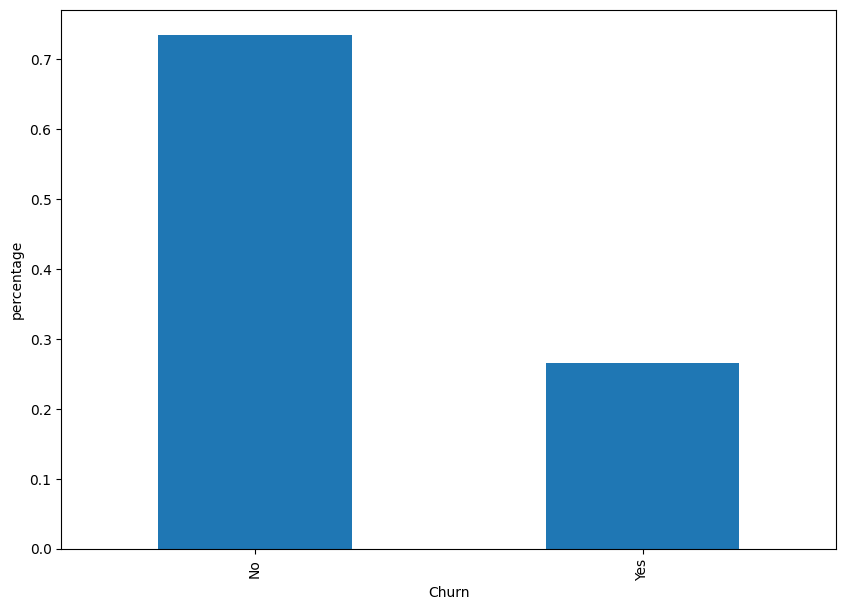

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
df['Churn'].value_counts(normalize=True).plot(kind='bar', ylabel='percentage')
# TODO: barplot
plt.show()


## 4. Числовые признаки: tenure, MonthlyCharges, TotalCharges


            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000


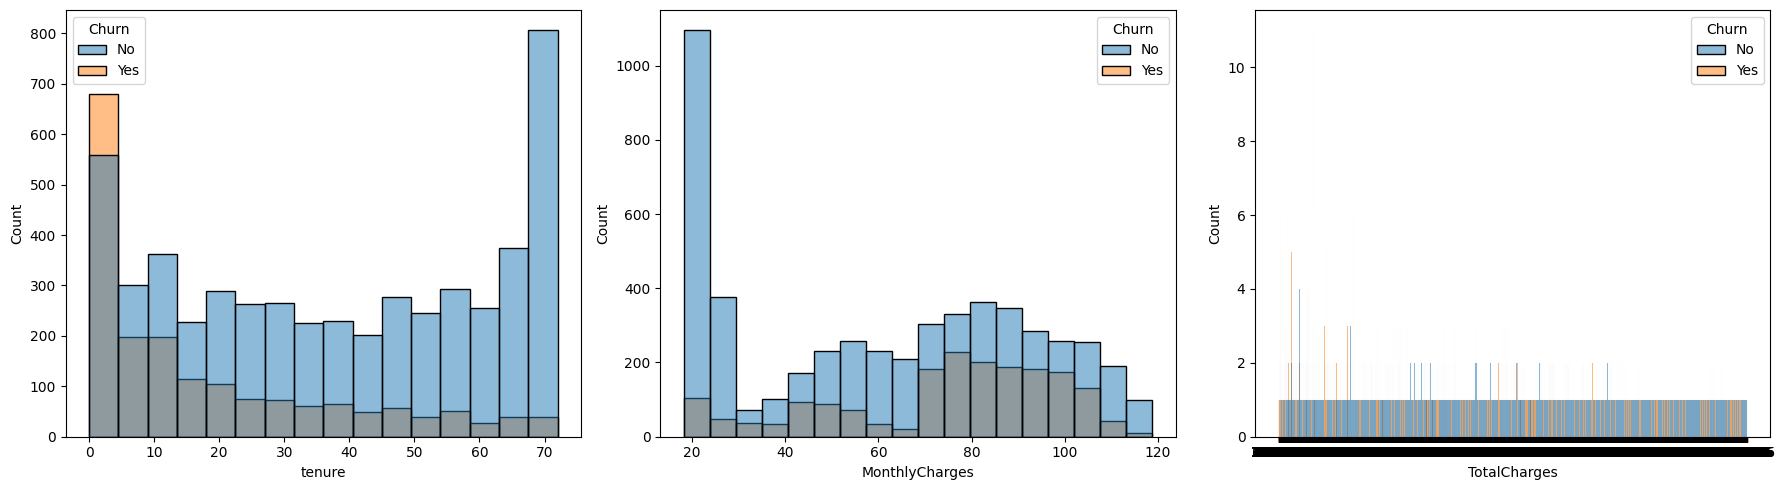

In [8]:
# TODO: гистограммы / boxplot по Churn
import seaborn as sns
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[0])
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[1])
sns.histplot(data=df, x='TotalCharges', hue='Churn', ax=axes[2])

plt.tight_layout()
plt.show()


## 5. Категориальные признаки vs Churn
Contract, PaymentMethod, InternetService и т.д.


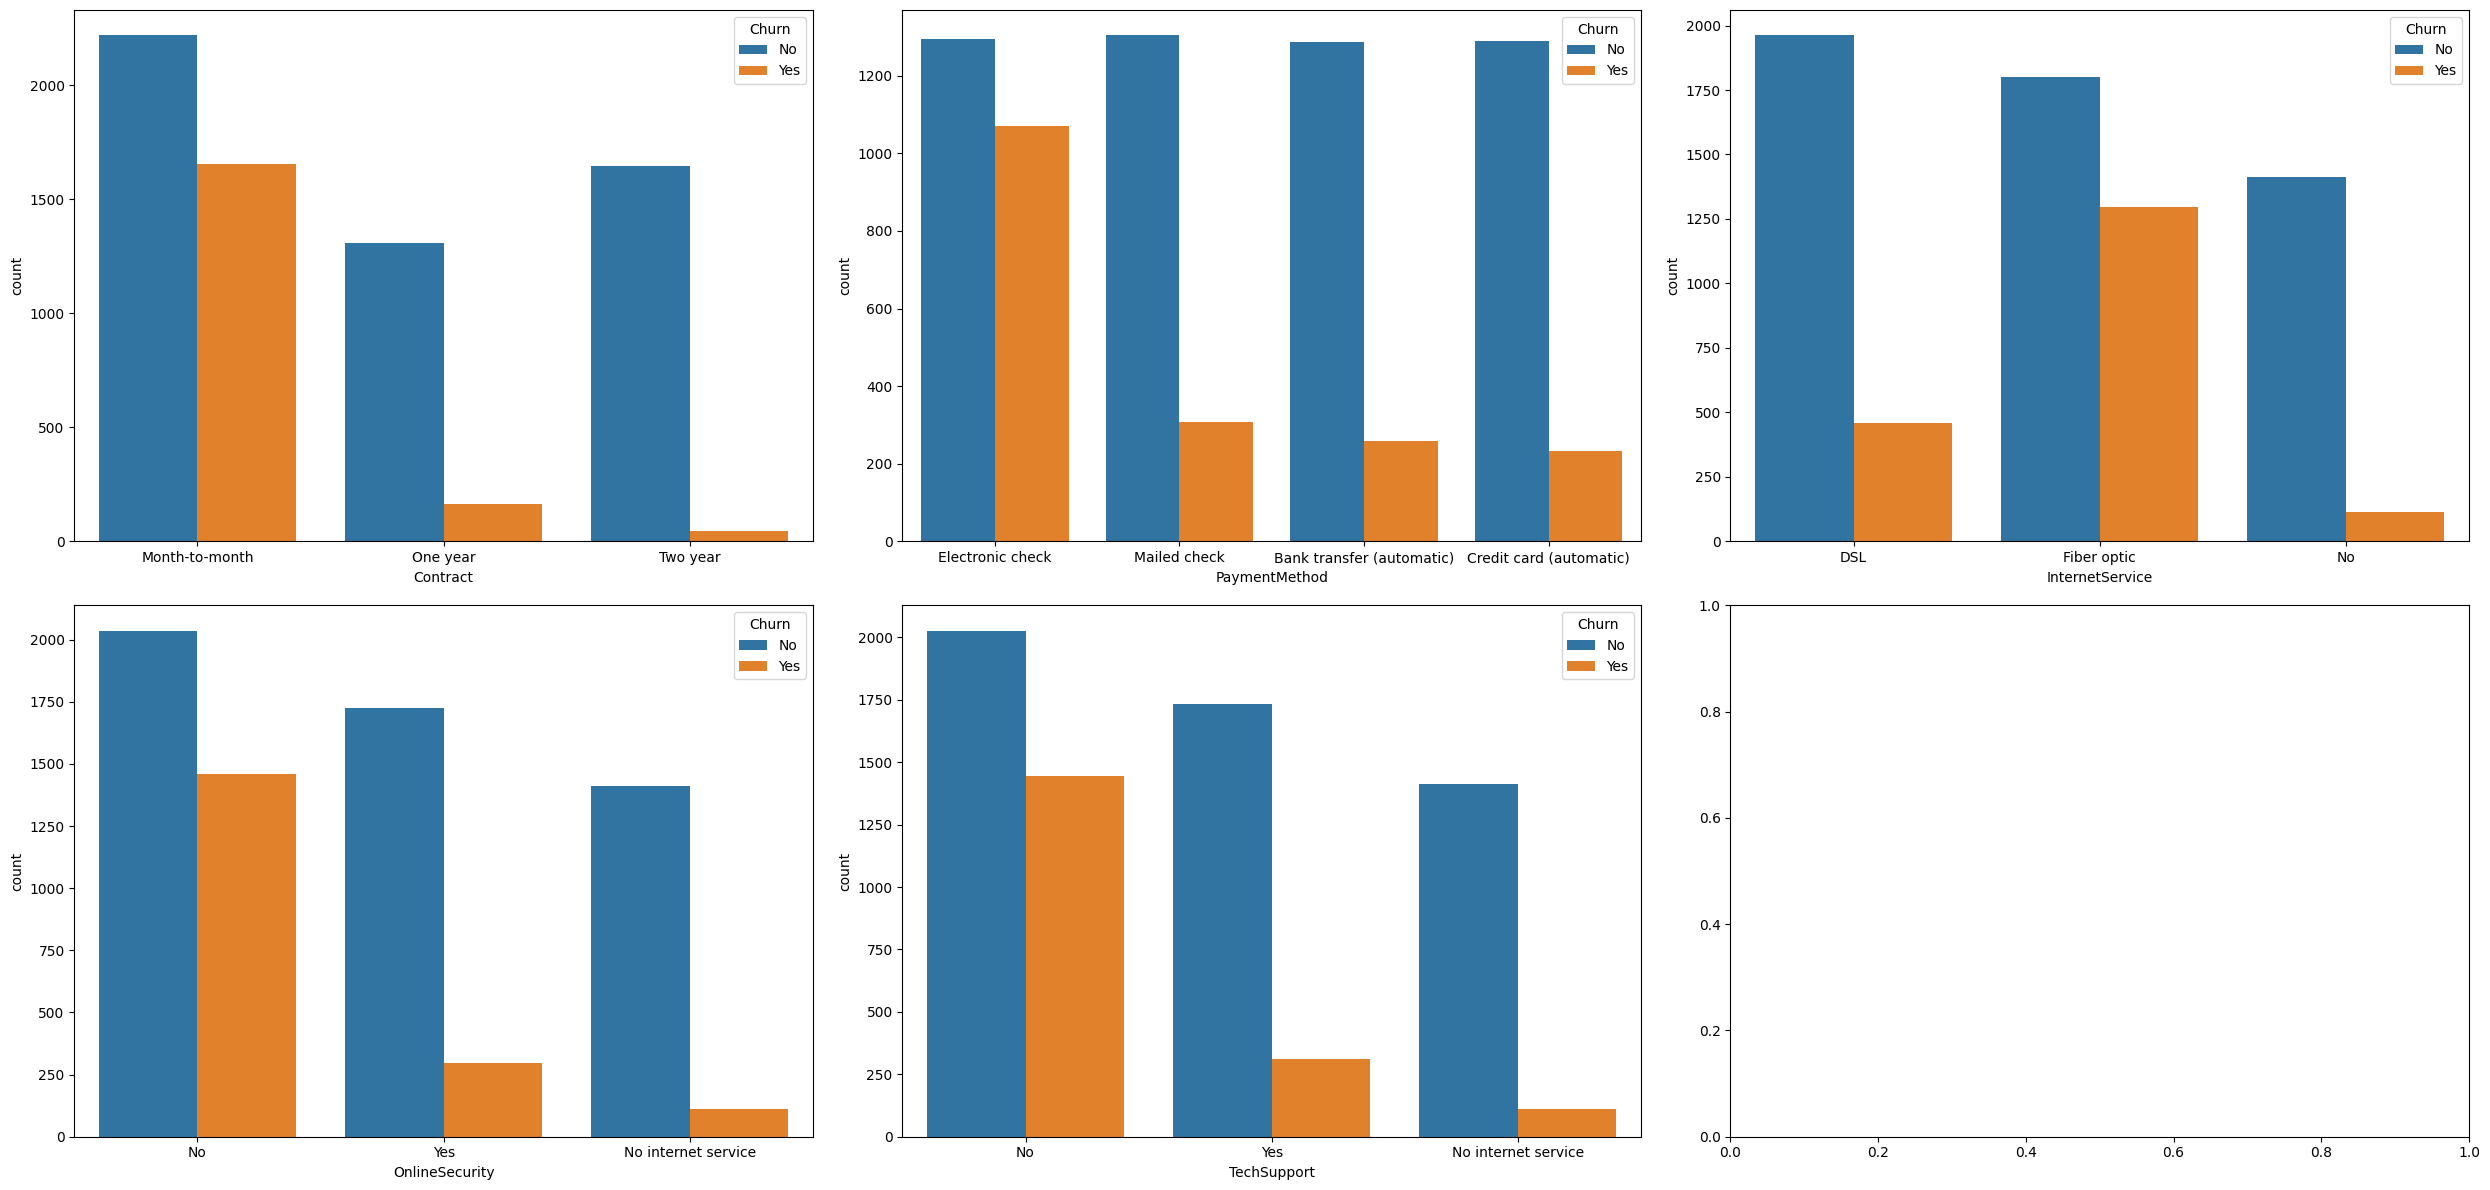

In [13]:
# TODO: countplot/barplot по каждой категориальной фиче с разбивкой по Churn
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0][0])
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0][1])
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0][2])
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[1][0])
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1][1])

plt.tight_layout()
plt.show()

## 6. Корреляции


<Axes: >

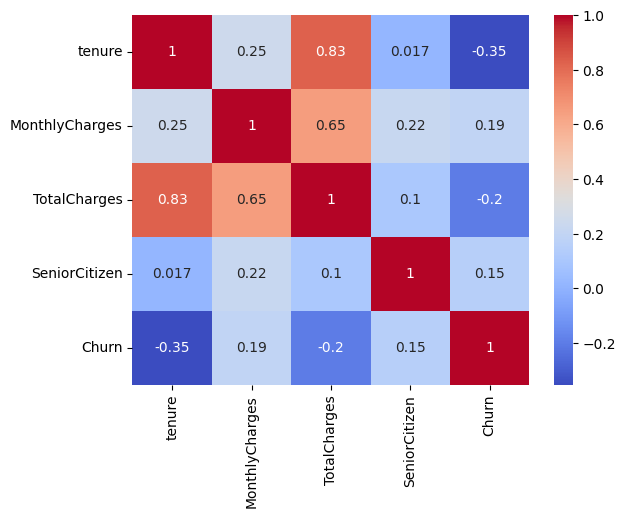

In [14]:
# TODO: corr heatmap для числовых признаков
import numpy as np

df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

## 7. Выводы EDA

**1. Какой признак сильнее всего связан с оттоком?**

`tenure` — срок пребывания клиента в компании (в месяцах). Корреляция с оттоком: -0.35.
Чем дольше клиент пользуется услугами, тем меньше вероятность, что он уйдёт.
Новые клиенты (tenure 0–6 месяцев) уходят значительно чаще.

**2. Какая категория клиентов уходит чаще?**

- По `Contract`: клиенты с договором "Month-to-month" уходят в ~40% случаев,
  тогда как "Two year" — менее 3%. Тип договора — сильнейший категориальный предиктор.
- По `PaymentMethod`: клиенты, платящие "Electronic check", уходят заметно чаще,
  чем клиенты с автоплатежом ("Bank transfer", "Credit card").
- По `InternetService`: клиенты с "Fiber optic" уходят чаще, чем с "DSL" или без интернета.

**3. Что нужно почистить перед моделированием?**

- `TotalCharges` имеет тип `object` вместо `float64` — 11 строк содержат пробел вместо числа.
  Это новые клиенты с `tenure == 0`, которым ещё не выставляли счёт. Нужно заменить на `0`.
- `SeniorCitizen` закодирован как int (0/1), но по смыслу — категориальный признак.
- В столбцах услуг (`OnlineSecurity`, `TechSupport` и др.) значение "No internet service"
  дублирует информацию из `InternetService == "No"` — при OHE создаёт избыточные признаки.

**Дисбаланс классов:** Churn=Yes — 26.5%, Churn=No — 73.5%.
Accuracy — плохая метрика для этой задачи. Ориентируемся на F1, ROC-AUC, PR-AUC.